In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from pathlib import Path
from PIL import Image
import numpy as np

In [31]:
train_data = pd.read_csv("../data/train.csv")
train_data.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


In [32]:
train_data = train_data.drop("sample_id",axis=1)

In [33]:
meta_cols = [
    "image_path", "Sampling_Date", "State", "Species",
    "Pre_GSHH_NDVI", "Height_Ave_cm"
]

pivoted_train = train_data.pivot_table(
    index=[col for col in meta_cols],
    columns="target_name",
    values="target"
).reset_index()

pivoted_train.head()


target_name,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,2015/4/1,NSW,Lucerne,0.55,16.0000,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,2015/5/18,Tas,Ryegrass,0.66,5.0000,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,2015/9/11,Tas,Ryegrass,0.54,3.5000,0.4343,23.2239,10.5261,34.1844,10.9605


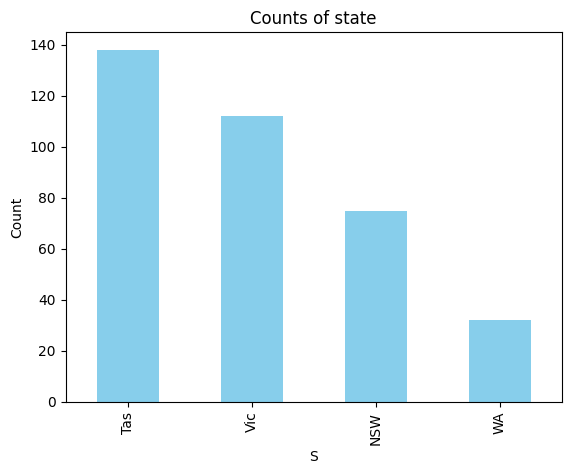

In [34]:
counts = pivoted_train["State"].value_counts()
counts.plot(kind='bar', color='skyblue')
plt.xlabel('S')
plt.ylabel('Count')
plt.title('Counts of state')
plt.show()

In [35]:
counts = pivoted_train["Species"].value_counts()
counts

Species
Ryegrass_Clover                                                98
Ryegrass                                                       62
Phalaris_Clover                                                42
Clover                                                         41
Fescue                                                         28
Lucerne                                                        22
Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed    11
Fescue_CrumbWeed                                               10
WhiteClover                                                    10
Phalaris                                                        8
Phalaris_Ryegrass_Clover                                        8
Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass                 7
SubcloverLosa                                                   5
SubcloverDalkeith                                               3
Mixed                                                           2
Na

In [36]:
counts["Phalaris_SilverGrass"] = counts["Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed"]
counts["Phalaris_BromeGrass"] = counts["Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass"]


In [37]:
del counts["Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed"]
del counts["Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass"]
# cut down on very long names

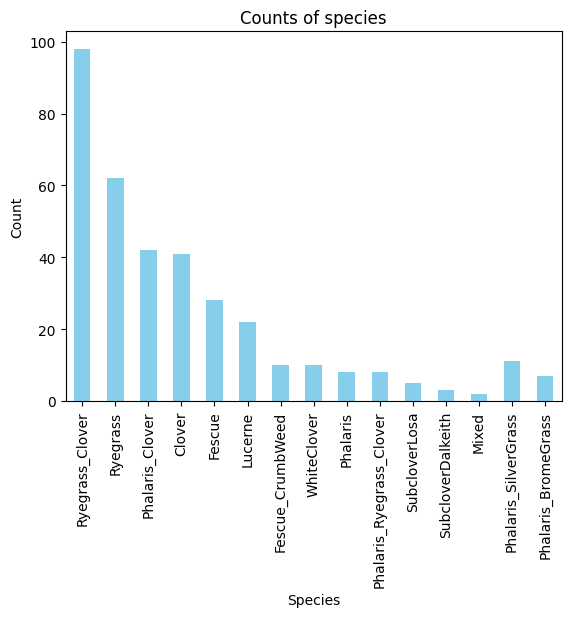

In [38]:
counts.plot(kind='bar', color='skyblue')
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Counts of species')
plt.show()

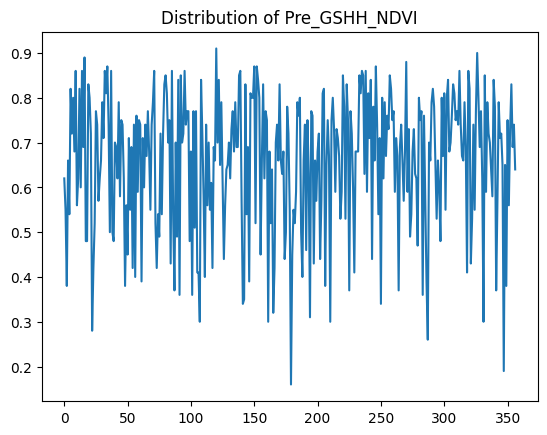

In [39]:
plt.clf()
Pre_GSHH_NDVI = pivoted_train["Pre_GSHH_NDVI"]
plt.plot(Pre_GSHH_NDVI)
plt.title("Distribution of Pre_GSHH_NDVI")
plt.show()

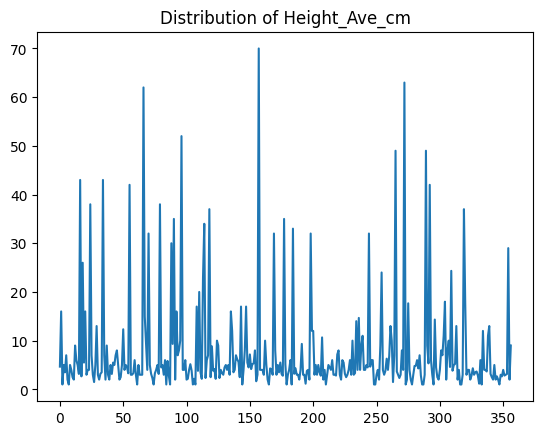

In [40]:
plt.clf()
Height_Ave_cm = pivoted_train["Height_Ave_cm"]
plt.plot(Height_Ave_cm)
plt.title("Distribution of Height_Ave_cm")
plt.show()

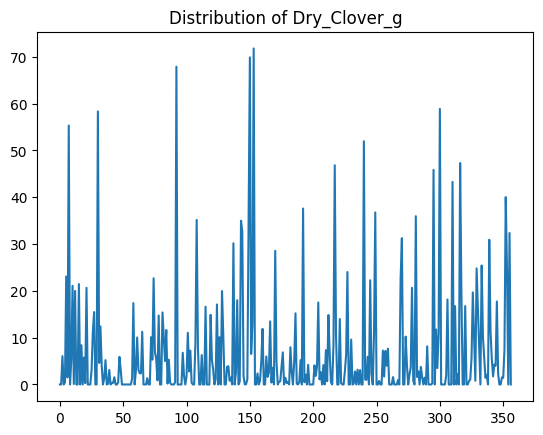

In [41]:
plt.clf()
Dry_Clover_g = pivoted_train["Dry_Clover_g"]
plt.plot(Dry_Clover_g)
plt.title("Distribution of Dry_Clover_g")
plt.show()

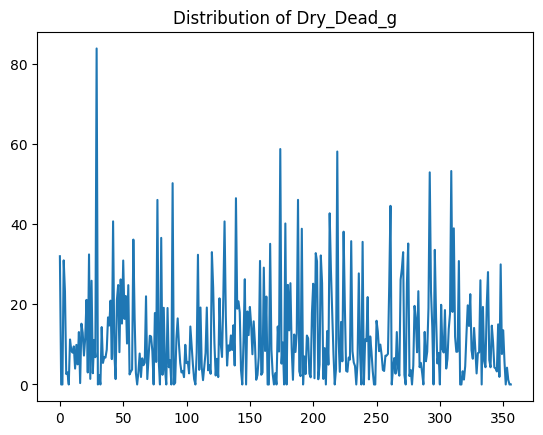

In [42]:
plt.clf()
Dry_Dead_g = pivoted_train["Dry_Dead_g"]
plt.plot(Dry_Dead_g)
plt.title("Distribution of Dry_Dead_g")
plt.show()

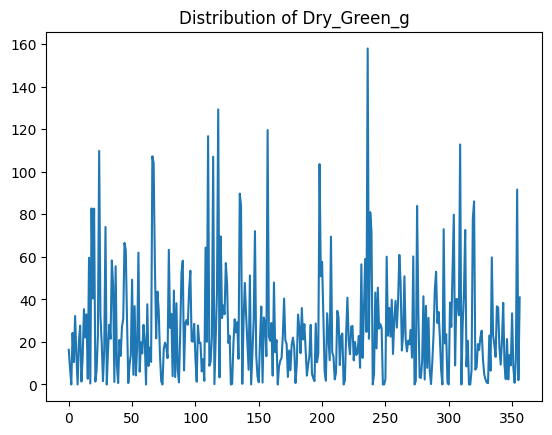

In [43]:
plt.clf()
Dry_Green_g = pivoted_train["Dry_Green_g"]
plt.plot(Dry_Green_g)
plt.title("Distribution of Dry_Green_g")
plt.show()

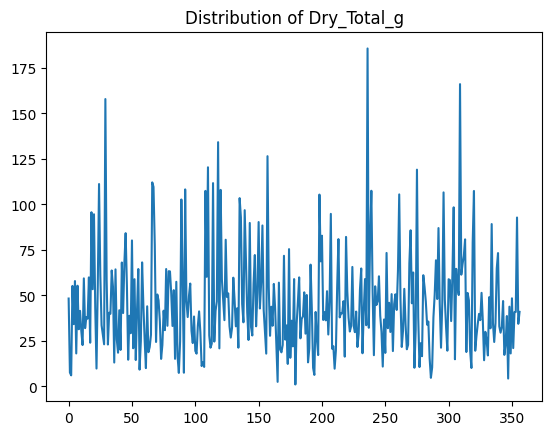

In [44]:
plt.clf()
Dry_Total_g = pivoted_train["Dry_Total_g"]
plt.plot(Dry_Total_g)
plt.title("Distribution of Dry_Total_g")
plt.show()

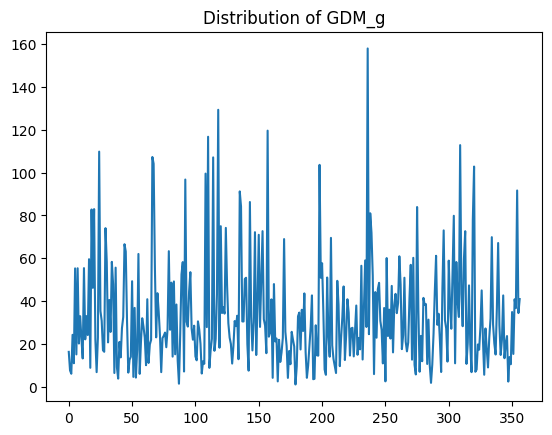

In [45]:
GDM_g = pivoted_train["GDM_g"]
plt.plot(GDM_g)
plt.title("Distribution of GDM_g")
plt.show()

In [46]:
sub_train = pivoted_train[[
                        #    "Sampling_Date",
                        #    "State",
                        #    "Species",
                           "Pre_GSHH_NDVI",
                           "Height_Ave_cm",
                           "Dry_Clover_g",
                           "Dry_Dead_g",
                           "Dry_Green_g",
                           "Dry_Total_g",
                           "GDM_g",
                           ]
                           ]

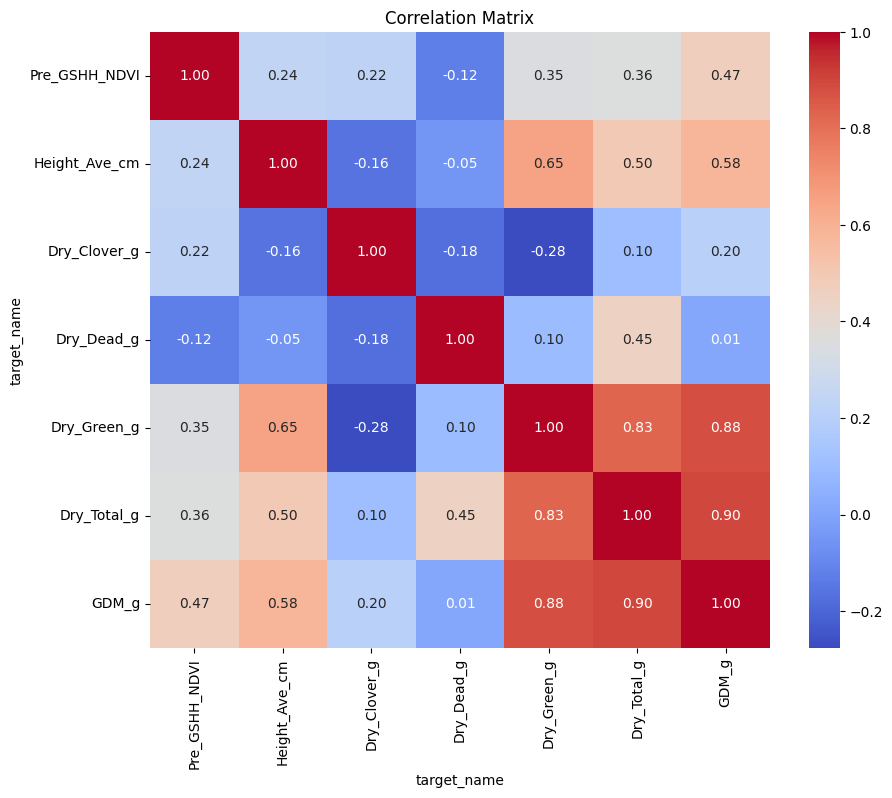

In [47]:
plt.figure(figsize=(10, 8))
sns.heatmap(sub_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

This is interesting, but is a bit misguiding since some of the features are specifically combinations of other features. Lets take a look at a more refined correlation matrix.

In [48]:
sub_train = pivoted_train[[
                        #    "Sampling_Date",
                        #    "State",
                        #    "Species",
                           "Dry_Clover_g",
                           "Dry_Dead_g",
                           "Dry_Green_g",
                           ]
                           ]

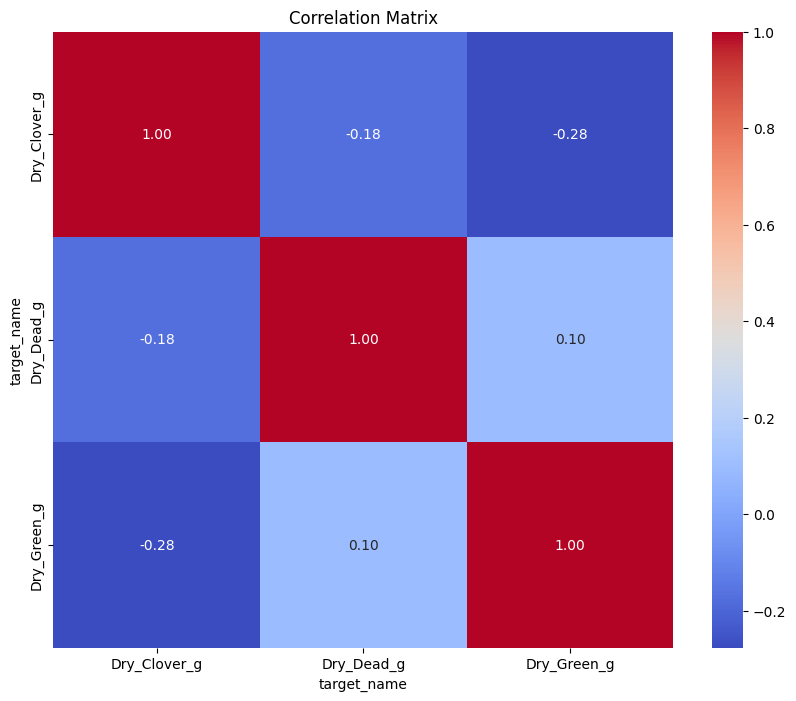

In [49]:
plt.figure(figsize=(10, 8))
sns.heatmap(sub_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

These features are not combination of other features, they are all indepedant measurements.
Interestingly, Dry clovers and Dry green are negativley correlated. Perhaps a patch of grass seems to mainly contain one kind of foilage.
The dead dry soil is negativley correlated with clovers, but positivley corellated with green grass.
Perhaps this says something about the growing conditions of the two plant species.

Now on to the images:

In [50]:
data_path_img = Path("../data/train")

# collect all image paths (adjust extensions if needed)
img_paths = list(data_path_img.rglob("*.jpg"))

print(f"Found {len(img_paths)} images")

Found 357 images


In [51]:
all_pixels = []

for img_path in img_paths:
    img = Image.open(img_path).convert("RGB")
    arr = np.array(img)  # shape: (H, W, C)
    all_pixels.append(arr.flatten())

all_pixels = np.concatenate(all_pixels)

In [52]:
def plot_pixel_distribution(all_pixels, title=""):
    plt.figure(figsize=(8,5))
    plt.hist(all_pixels, bins=50, color='blue', edgecolor='black', density=True)
    plt.xlabel("Pixel value")
    plt.ylabel("Frequency")
    plt.title(f"Pixel value distribution in train set | {title}")
    plt.tight_layout()
    plt.show()

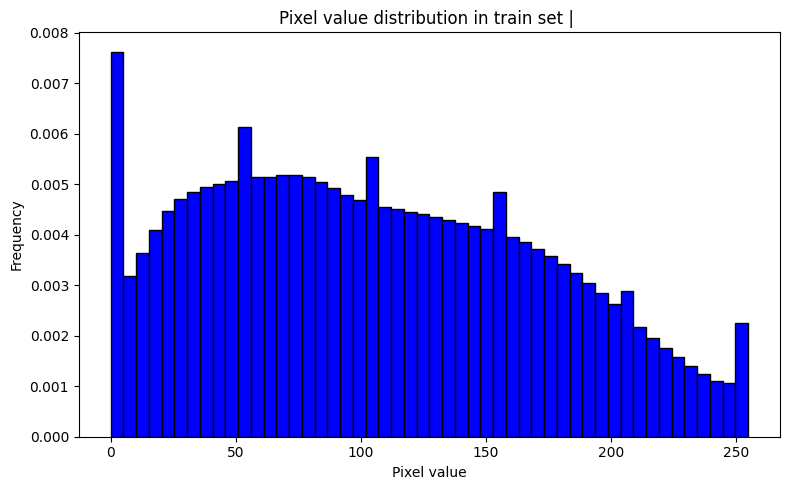

In [ ]:
plot_pixel_distribution(all_pixels)

In [78]:
def plot_pixel_per_state(train_inp, state):
    imgs_pivot = train_inp[train_inp["State"] == state]
    imgs = imgs_pivot["image_path"]

    all_pixels_state = []
    for img_path in img_paths:
        fname = f"train/{img_path.stem}.jpg"
        if imgs.str.contains(fname).any():
            img = Image.open(img_path).convert("RGB")
            arr = np.array(img)  # shape: (H, W, C)
            all_pixels_state.append(arr.flatten())

    all_pixels_state = np.concatenate(all_pixels_state)
    return all_pixels_state

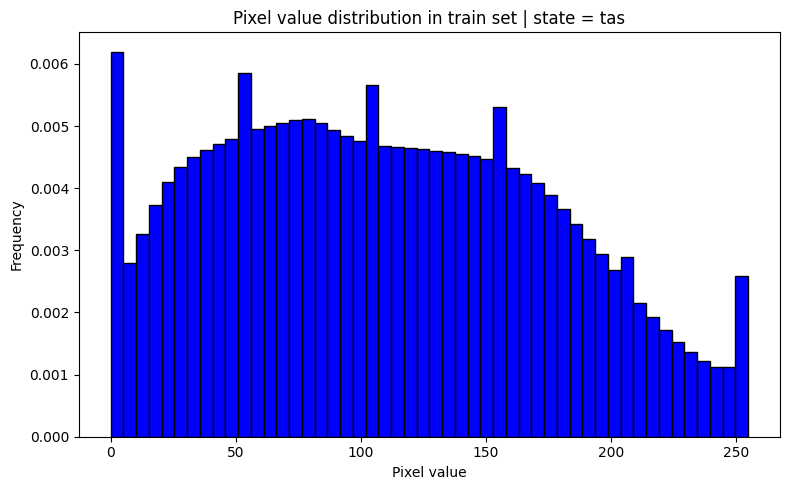

In [79]:
all_pixels_tas = plot_pixel_per_state(pivoted_train, "Tas")
plot_pixel_distribution(all_pixels_tas, title="state = tas")

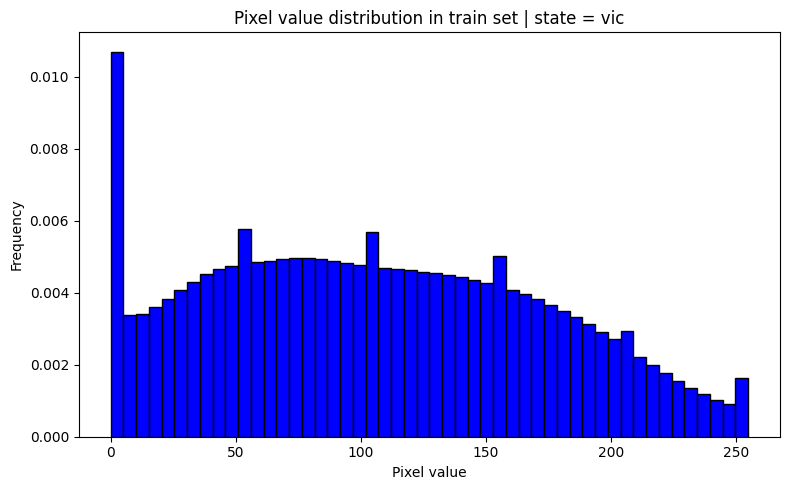

In [80]:
all_pixels_vic = plot_pixel_per_state(pivoted_train, "Vic")
plot_pixel_distribution(all_pixels_vic, title="state = vic")

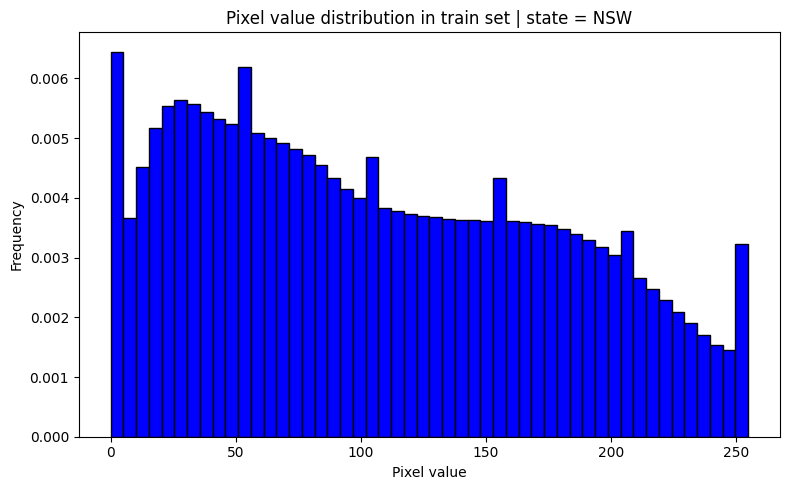

In [82]:
all_pixels_wa = plot_pixel_per_state(pivoted_train, "NSW")
plot_pixel_distribution(all_pixels_wa, title="state = NSW")

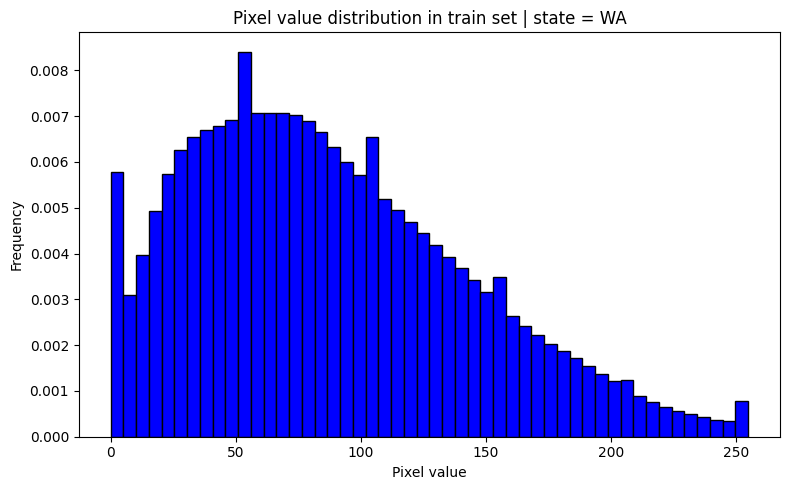

In [83]:
all_pixels_wa = plot_pixel_per_state(pivoted_train, "WA")
plot_pixel_distribution(all_pixels_wa, title="state = WA")